# Imports


In [1]:
from pathlib import Path
import json
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_DIR = Path("./") #Path.home() / "Documents" / "GitHub" / "CORI_dev"
SRC_DIR = PROJECT_DIR / "code/src"
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

from src.data import (
    TREATMENT_COLUMNS,
    cohort_audit,
    load_clinical,
    load_cohort,
    load_sites,
    load_treatment,
    merge_columns,
    collapse_cmr_columns,
    read_csv,
)
from src.models import (
    train_model,
    tune_model_cv,
    out_of_fold_score,
    score_model,
    score_values,
    predict_risk,
    save_model,
)
from src.metrics import (
    adjusted_cox,
    baseline_table,
    categorical_nri,
    c_index,
    fit_cox_columns,
    handcrafted_replication_table,
    high_low_hr,
    horizon_table,
    idi,
    likelihood_ratio_test,
    paired_delta_c,
    performance_row,
    reclassification_tables,
    residualize,
    stratified_incremental_test,
    subgroup_cox,
)
from src.matching import (
    matched_mmace_ensemble,
    information_matched_learning_curve,
    matched_curve_summary,
)
from src.plots import (
    calibration_plot,
    forest_plot,
    km_plot,
    learning_curve_plot,
    rank_transition,
    reclassification_heatmap,
)
from src.specificity import (
    dual_score_interaction_test,
    interaction_replication,
    permuted_replication_p,
    score_interaction_test,
)
from src.cmr import (
    association_table,
    domain_acat,
    domain_pc_table,
    signed_domain_association_table,
)

SEED = 20260714
np.random.seed(SEED)

# Data paths

In [2]:
DATA_DIR = PROJECT_DIR / "data"
CLEAN_DIR = DATA_DIR / "CLEAN_COHORTS_21JUL"

OUTPUT_DIR = PROJECT_DIR / "outputs_refactored"
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR = OUTPUT_DIR / "figures"
MODEL_DIR = OUTPUT_DIR / "models"
SCORE_DIR = OUTPUT_DIR / "scores"
QC_DIR = OUTPUT_DIR / "qc"

for directory in [TABLE_DIR, FIGURE_DIR, MODEL_DIR, SCORE_DIR, QC_DIR]:
    directory.mkdir(parents=True, exist_ok=True)


COHORT_FILES = {
    "D1":  "./data/CORI_input_files_21Jul/D1_CORI_cancer_development_train_ready_f1024.csv",
    "D2": "./data/CORI_input_files_21Jul/D2_CORI_cancer_heldout_train_ready_f1024.csv",
    "D3": "./data/CORI_input_files_21Jul/D3_MMACEv2_never_cancer_development_train_ready_f1024.csv",
    "D4": "./data/CORI_input_files_21Jul/D4_MMACEv2_never_cancer_heldout_train_ready_f1024.csv",
    "D6": "./data/CORI_input_files_21Jul/D6_CMR_subset_train_ready_f1024.csv",
} 

# Preserve the historical variable name so downstream cells remain unchanged.
MEANPOOL_FILES = COHORT_FILES

CLINICAL_FILE = DATA_DIR / "final_df_HTN_DB_Status.csv"
TREATMENT_FILE = DATA_DIR / "risk_score_df_final_shared_22April_2026.csv"
CANCER_SITE_FILE = DATA_DIR / "CORI_allcancer_8Jan2026.csv"
CMR_FILE = DATA_DIR / "cardiac_mri.csv"
HANDCRAFTED_FILE = DATA_DIR / "H1_handcrafted_subject_level_features_cached.csv"

DEEP_FEATURES = [f"f{i}" for i in range(1024)]
FEATURE_VIEW_COLUMN = "feature_prefix_used"
FEATURE_SOURCE_COLUMN = "source_name"

CLINICAL_VARIABLES = ["age", "female", "height", "Diabetes", "HTN"]
PRIMARY_ADJUSTMENT = ["age", "female", "Diabetes", "HTN"]
MATCH_VARIABLES = ["age", "female", "height"]
CANCER_SITE_COLUMNS = [
    "DigestiveCancer_present", "RespiCancer_present", "BreastCancer_present",
    "FemRepoCancer_present", "MaleRepoCancer_present", "UrinaryTractCancer_present",
    "EndocrineCancer_present", "HeamatoCancer_present", "InsituCancer_present",
    "LipOralCancer_present", "BoneCancer_present", "SkinCancer_present",
    "MesotheliumCancer_present", "EyeCNSCancer_present", "SecondaryCancer_present",
    "UnknownCancer_present",
]


TUNING_K = [10, 15, 20]
TUNING_PENALTIES = [0.001, 0.01, 0.05, 0.1]
TUNING_FOLDS = 3
TUNING_REPEATS = 3
TUNING_RULE = "one_se"

BOOTSTRAPS = 1000
MATCHED_REPETITIONS = 200
CRUDE_MATCHED_REPETITIONS = 200

RUN_FULL_LEARNING_CURVE = True
RUN_ALL_REPRESENTATIONS = False
RUN_HANDCRAFTED = True
RUN_CMR = True
RUN_CROSSFIT_MEDIATION = True

# Records the explicit decision to retain both pre-existing
# RETFound-derived feature provenance groups in the train-ready cohorts.
ALLOW_MIXED_RETFOUND_VIEWS = True


In [3]:
def save_table(df, name):
    path = TABLE_DIR / f"{name}.csv"
    df.to_csv(path, index=False)
    print(path)
    return df


def add_groups(df, score_column, thresholds, prefix):
    out = df.copy()
    out[f"{prefix}_high"] = (out[score_column] > thresholds["median"]).astype(int)
    out[f"{prefix}_tertile"] = pd.cut(
        out[score_column],
        [-np.inf, thresholds["tertile_1"], thresholds["tertile_2"], np.inf],
        labels=["Low", "Middle", "High"],
        include_lowest=True,
    ).astype(str)
    return out


def score_thresholds(values):
    values = np.asarray(values, dtype=float)
    return {
        "median": float(np.quantile(values, 0.50)),
        "tertile_1": float(np.quantile(values, 1 / 3)),
        "tertile_2": float(np.quantile(values, 2 / 3)),
    }


# Load data

In [4]:
# ============================================================
# Load train-ready RETFound-derived cohorts
# ============================================================

meanpool = {
    cohort: load_cohort(COHORT_FILES[cohort], DEEP_FEATURES)
    for cohort in COHORT_FILES.keys()
}

# Harmonize the authoritative cancer indicator and retain provenance.
for cohort, cohort_df in meanpool.items():
    if "A_cancer_primary" in cohort_df.columns:
        cohort_df["A_cancer"] = pd.to_numeric(
            cohort_df["A_cancer_primary"],
            errors="raise",
        ).astype(int)

    if FEATURE_VIEW_COLUMN not in cohort_df.columns:
        cohort_df[FEATURE_VIEW_COLUMN] = "unknown"

    if FEATURE_SOURCE_COLUMN not in cohort_df.columns:
        cohort_df[FEATURE_SOURCE_COLUMN] = "unknown"

    cohort_df[FEATURE_VIEW_COLUMN] = (
        cohort_df[FEATURE_VIEW_COLUMN]
        .fillna("unknown")
        .astype(str)
        .str.strip()
    )
    cohort_df[FEATURE_SOURCE_COLUMN] = (
        cohort_df[FEATURE_SOURCE_COLUMN]
        .fillna("unknown")
        .astype(str)
        .str.strip()
    )

    # Retained for optional provenance-adjusted sensitivity analyses.
    cohort_df["feature_view_emb2"] = (
        cohort_df[FEATURE_VIEW_COLUMN]
        .eq("emb2_f")
        .astype(int)
    )


# ============================================================
# Merge approved external metadata exactly as before
# ============================================================

clinical = load_clinical(CLINICAL_FILE)
treatment = load_treatment(TREATMENT_FILE)
sites = load_sites(CANCER_SITE_FILE, CANCER_SITE_COLUMNS)

for cohort in ["D1", "D2", "D3", "D4", "D6"]:
    meanpool[cohort] = merge_columns(meanpool[cohort], clinical)

for cohort in ["D1", "D2", "D6"]:
    meanpool[cohort] = merge_columns(meanpool[cohort], treatment)

for cohort in ["D1", "D2", "D6"]:
    meanpool[cohort] = merge_columns(meanpool[cohort], sites)

meanpool["D1"]["split"] = "Development"
meanpool["D2"]["split"] = "Held-out"
meanpool["D3"]["split"] = "Development"
meanpool["D4"]["split"] = "Held-out"


In [6]:
cancer_all = pd.concat([meanpool["D1"], meanpool["D2"]], ignore_index=True)
table_1 = baseline_table(
    cancer_all,
    group_column="split",
    continuous=["age", "height"],
    categorical=["female", "Diabetes", "HTN", "Y_mace"],
)
display(table_1)
# save_table(table_1, "Table_01_baseline_characteristics_D1_D2")


time_col = "time_years"
event_col = "Y_mace"

display(cancer_all[time_col].describe())
display(cancer_all[event_col].describe())

Noncancer_all = pd.concat([meanpool["D3"], meanpool["D4"]], ignore_index=True)
table_1 = baseline_table(
    Noncancer_all,
    group_column="split",
    continuous=["age", "height"],
    categorical=["female", "Diabetes", "HTN", "Y_mace"],
)
display(table_1)
# save_table(table_1, "Table_01_baseline_characteristics_D1_D2")

display(Noncancer_all[time_col].describe())
display(Noncancer_all[event_col].describe())

,variable,Overall,Development,Held-out
0,age,57.6 (7.7),57.4 (7.8),57.8 (7.7)
1,height,166.9 (8.8),166.6 (8.7),167.2 (8.8)
2,female,"3,164 (68.9%)","1,523 (70.6%)","1,641 (67.4%)"
3,Diabetes,214 (4.7%),102 (4.7%),112 (4.6%)
4,HTN,"1,221 (26.6%)",595 (27.6%),626 (25.7%)
5,Y_mace,635 (13.8%),300 (13.9%),335 (13.8%)


count    4591.000000
mean        9.107704
std         2.215997
min         0.008214
25%         9.993155
50%         9.993155
75%         9.993155
max         9.998631
Name: time_years, dtype: float64

count    4591.000000
mean        0.138314
std         0.345267
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: Y_mace, dtype: float64

,variable,Overall,Development,Held-out
0,age,54.8 (8.2),54.6 (8.2),54.9 (8.2)
1,height,168.9 (9.3),168.7 (9.3),169.1 (9.2)
2,female,"15,983 (55.3%)","7,913 (55.9%)","8,070 (54.7%)"
3,Diabetes,"1,068 (3.7%)",544 (3.8%),524 (3.5%)
4,HTN,"6,248 (21.6%)","3,093 (21.8%)","3,155 (21.4%)"
5,Y_mace,"2,809 (9.7%)","1,348 (9.5%)","1,461 (9.9%)"


count    28922.000000
mean         9.588569
std          1.532134
min          0.008214
25%          9.998631
50%          9.998631
75%          9.998631
max          9.998631
Name: time_years, dtype: float64

count    28922.000000
mean         0.097123
std          0.296131
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: Y_mace, dtype: float64

In [7]:

def preprocess_features(train_df, test_df, test2_df, test3_df, candidate, var_threshold=0.01, corr_threshold=0.9, verbose=True):
    for col in candidate:
        p1 = train_df[col].quantile(0.01)
        p99 = train_df[col].quantile(0.99)
        train_df[col] = train_df[col].clip(p1, p99)
        test_df[col] = test_df[col].clip(p1, p99)
        test2_df[col] = test2_df[col].clip(p1, p99)
        test3_df[col] = test3_df[col].clip(p1, p99)

    mean_vals = train_df[candidate].mean()
    std_vals = train_df[candidate].std()

    train_df[candidate] = (train_df[candidate] - mean_vals) / std_vals
    test_df[candidate] = (test_df[candidate] - mean_vals) / std_vals
    test2_df[candidate] = (test2_df[candidate] - mean_vals) / std_vals
    test3_df[candidate] = (test3_df[candidate] - mean_vals) / std_vals
    
    var = train_df[candidate].var()
    candidate = var[var > var_threshold].index.tolist()

    if verbose:
        print("After variance filtering:", len(candidate))

    corr = train_df[candidate].corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    to_drop = [c for c in upper.columns if any(upper[c] > corr_threshold)]
    candidate = [c for c in candidate if c not in to_drop]

    if verbose:
        print("After correlation filtering:", len(candidate))

    return train_df, test_df, test2_df, test3_df, candidate, mean_vals, std_vals

d1_coriPreProcess , d2_coriPreProcess , d3_coriPreProcess ,d4_coriPreProcess , Cori_filtered_features, mean_vals, std_vals = preprocess_features(meanpool["D1"], meanpool["D2"], meanpool["D3"], meanpool["D4"],
                                                                                     DEEP_FEATURES, var_threshold=0.1, 
                                                                                     corr_threshold=0.8, verbose=True)

d3_MMACEPreProcess , d4_MMACEPreProcess , d1_MMACEPreProcess , d2_MMACEPreProcess , MMACE_filtered_features, mean_vals, std_vals = preprocess_features(meanpool["D3"], meanpool["D4"], meanpool["D1"], meanpool["D2"],
                                                                                     DEEP_FEATURES, var_threshold=0.1, 
                                                                                     corr_threshold=0.8, verbose=True)



After variance filtering: 1024
After correlation filtering: 946
After variance filtering: 1024
After correlation filtering: 149


In [8]:
# cori_cohort_dict = {
#     "D1": d1_coriPreProcess,
#     "D2": d2_coriPreProcess,
#     "D4": d4_coriPreProcess,
# }

# mmace_cohort_dict = {
#     "D3": d3_MMACEPreProcess,
#     "D4": d4_MMACEPreProcess,
#     "D2": d2_MMACEPreProcess,
# }

meanpool['D1_cori'] = d1_coriPreProcess
meanpool['D2_cori'] = d2_coriPreProcess
meanpool['D3_cori'] = d3_coriPreProcess
meanpool['D4_cori'] = d4_coriPreProcess

meanpool['D1_mmace'] = d1_MMACEPreProcess
meanpool['D2_mmace'] = d2_MMACEPreProcess
meanpool['D3_mmace'] = d3_MMACEPreProcess
meanpool['D4_mmace'] = d4_MMACEPreProcess

# Disentanglement learning

In [35]:
"""
Disentangled multi-task learning: shared + private encoders for two label sets
(Y1, Y2) from a common feature input X.

Architecture
    X -> shared_encoder      -> E1 (shared embedding)
    X -> private_encoder_1   -> P1 (task-1-private embedding)
    X -> private_encoder_2   -> P2 (task-2-private embedding)
    [E1;P1] -> decoder_1 -> E2_1 -> classifier_1 -> Y1 logit
    [E1;P2] -> decoder_2 -> E2_2 -> classifier_2 -> Y2 logit
    (optional) [E1;P1] -> recon_1 -> X_hat_1
    (optional) [E1;P2] -> recon_2 -> X_hat_2

Losses
    - masked BCE per task (handles missing labels), combined via learned
      homoscedastic uncertainty weighting (Kendall et al. 2018)
    - DSN-style difference/orthogonality loss between E1 and each private embedding
    - optional reconstruction loss

Disentanglement diagnostics (printed during training)
    - task AUCs from the deployed classifiers (want: high, improving)
    - E1 -> Y1 / E1 -> Y2 linear-probe AUC (sanity: E1 should stay predictive of both)
    - P1 -> Y2 / P2 -> Y1 linear-probe AUC (leakage: should sit near chance, ~0.5,
      if the private embeddings are genuinely task-specific)
    - mean |cosine similarity| between E1 and each private embedding (want: shrinking toward 0)
"""

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score


# ---------------------------------------------------------------------------
# 1. Dataset / DataLoader
# ---------------------------------------------------------------------------

class MultiTaskDataset(Dataset):
    """Wraps X, Y1, Y2. Labels may contain NaN for missing entries; a per-sample
    mask is returned alongside each label so the loss can skip missing ones."""

    def __init__(self, X, Y1, Y2):
        self.X = torch.as_tensor(X, dtype=torch.float32)
        y1 = np.asarray(Y1, dtype=np.float32)
        y2 = np.asarray(Y2, dtype=np.float32)
        self.mask1 = torch.as_tensor(~np.isnan(y1), dtype=torch.float32)
        self.mask2 = torch.as_tensor(~np.isnan(y2), dtype=torch.float32)
        self.Y1 = torch.as_tensor(np.nan_to_num(y1, nan=0.0), dtype=torch.float32)
        self.Y2 = torch.as_tensor(np.nan_to_num(y2, nan=0.0), dtype=torch.float32)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.Y1[idx], self.Y2[idx], self.mask1[idx], self.mask2[idx]


def make_loaders(X_train, Y1_train, Y2_train, X_test, Y1_test, Y2_test, batch_size=128):
    train_ds = MultiTaskDataset(X_train, Y1_train, Y2_train)
    test_ds = MultiTaskDataset(X_test, Y1_test, Y2_test)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=True)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)
    return train_loader, test_loader


# ---------------------------------------------------------------------------
# 2. Model
# ---------------------------------------------------------------------------

def mlp(in_dim, out_dim, hidden=128):
    return nn.Sequential(
        nn.Linear(in_dim, hidden),
        nn.ReLU(inplace=True),
        nn.LayerNorm(hidden),
        nn.Linear(hidden, out_dim),
    )


class DisentangledMultiTaskNet(nn.Module):
    def __init__(self, in_dim, shared_dim=64, private_dim=32, e2_dim=32, use_recon=False):
        super().__init__()
        self.use_recon = use_recon

        self.shared_encoder = mlp(in_dim, shared_dim)
        self.private_encoder_1 = mlp(in_dim, private_dim)
        self.private_encoder_2 = mlp(in_dim, private_dim)

        self.decoder_1 = mlp(shared_dim + private_dim, e2_dim)
        self.decoder_2 = mlp(shared_dim + private_dim, e2_dim)

        self.classifier_1 = nn.Linear(e2_dim, 1)
        self.classifier_2 = nn.Linear(e2_dim, 1)

        if use_recon:
            self.recon_1 = mlp(shared_dim + private_dim, in_dim)
            self.recon_2 = mlp(shared_dim + private_dim, in_dim)

        # learned log-variance terms for uncertainty-weighted multi-task loss
        self.log_sigma1 = nn.Parameter(torch.zeros(()))
        self.log_sigma2 = nn.Parameter(torch.zeros(()))

    def forward(self, x):
        e1 = self.shared_encoder(x)
        p1 = self.private_encoder_1(x)
        p2 = self.private_encoder_2(x)

        e2_1 = self.decoder_1(torch.cat([e1, p1], dim=-1))
        e2_2 = self.decoder_2(torch.cat([e1, p2], dim=-1))

        logit1 = self.classifier_1(e2_1).squeeze(-1)
        logit2 = self.classifier_2(e2_2).squeeze(-1)

        out = {
            "e1": e1, "p1": p1, "p2": p2,
            "e2_1": e2_1, "e2_2": e2_2,
            "logit1": logit1, "logit2": logit2,
        }
        if self.use_recon:
            out["xhat1"] = self.recon_1(torch.cat([e1, p1], dim=-1))
            out["xhat2"] = self.recon_2(torch.cat([e1, p2], dim=-1))
        return out


# ---------------------------------------------------------------------------
# 3. Losses
# ---------------------------------------------------------------------------

def difference_loss(shared, private):
    """DSN-style soft orthogonality constraint: mean-center and L2-normalize
    both embeddings row-wise, then penalize the squared Frobenius norm of
    their cross-correlation. Pushes shared vs. private toward independent
    directions instead of encoding the same information twice."""
    s = shared - shared.mean(dim=0, keepdim=True)
    p = private - private.mean(dim=0, keepdim=True)
    s = nn.functional.normalize(s, dim=1)
    p = nn.functional.normalize(p, dim=1)
    corr = torch.matmul(s.t(), p)
    return (corr ** 2).mean()


def masked_bce(logits, targets, mask, pos_weight=None):
    if mask.sum() == 0:
        return logits.sum() * 0.0  # no labels in this batch; keep graph valid, contribute 0
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight, reduction="none")
    per_sample = loss_fn(logits, targets)
    return (per_sample * mask).sum() / mask.sum().clamp(min=1.0)


def compute_losses(out, y1, y2, m1, m2, x, pos_weight1, pos_weight2,
                    lambda_orth, lambda_recon, model):
    task1_loss = masked_bce(out["logit1"], y1, m1, pos_weight1)
    task2_loss = masked_bce(out["logit2"], y2, m2, pos_weight2)

    # homoscedastic uncertainty weighting (Kendall, Gal & Cipolla 2018)
    weighted_task_loss = (
        torch.exp(-model.log_sigma1) * task1_loss + model.log_sigma1
        + torch.exp(-model.log_sigma2) * task2_loss + model.log_sigma2
    )

    orth1 = difference_loss(out["e1"], out["p1"])
    orth2 = difference_loss(out["e1"], out["p2"])
    orth_loss = orth1 + orth2

    total = weighted_task_loss + lambda_orth * orth_loss

    recon_loss = torch.tensor(0.0, device=x.device)
    if lambda_recon > 0 and "xhat1" in out:
        recon_loss = (
            nn.functional.mse_loss(out["xhat1"], x) + nn.functional.mse_loss(out["xhat2"], x)
        )
        total = total + lambda_recon * recon_loss

    return {
        "total": total,
        "task1": task1_loss.detach(),
        "task2": task2_loss.detach(),
        "orth1": orth1.detach(),
        "orth2": orth2.detach(),
        "recon": recon_loss.detach(),
    }


# ---------------------------------------------------------------------------
# 4. Disentanglement diagnostics
# ---------------------------------------------------------------------------

def safe_auc(y_true, scores):
    if len(np.unique(y_true)) < 2:
        return float("nan")
    return roc_auc_score(y_true, scores)


@torch.no_grad()
def extract_embeddings(model, loader, device):
    model.eval()
    E1, P1, P2, Y1, Y2, M1, M2 = [], [], [], [], [], [], []
    for x, y1, y2, m1, m2 in loader:
        x = x.to(device)
        out = model(x)
        E1.append(out["e1"].cpu().numpy())
        P1.append(out["p1"].cpu().numpy())
        P2.append(out["p2"].cpu().numpy())
        Y1.append(y1.numpy()); Y2.append(y2.numpy())
        M1.append(m1.numpy()); M2.append(m2.numpy())
    cat = lambda arrs: np.concatenate(arrs, axis=0)
    return cat(E1), cat(P1), cat(P2), cat(Y1), cat(Y2), cat(M1), cat(M2)


def probe_auc(train_feat, train_label, train_mask, test_feat, test_label, test_mask):
    """Fit a small linear probe on train embeddings -> label, score AUC on
    held-out test embeddings. Used both as a sanity check (E1 -> its own task)
    and as a leakage check (P1 -> the OTHER task)."""
    tr_idx = train_mask > 0.5
    te_idx = test_mask > 0.5
    if tr_idx.sum() < 10 or te_idx.sum() < 10 or len(np.unique(train_label[tr_idx])) < 2:
        return float("nan")
    clf = LogisticRegression(max_iter=1000)
    clf.fit(train_feat[tr_idx], train_label[tr_idx])
    scores = clf.predict_proba(test_feat[te_idx])[:, 1]
    return safe_auc(test_label[te_idx], scores)


def cosine_overlap(shared, private):
    s = shared / (np.linalg.norm(shared, axis=1, keepdims=True) + 1e-8)
    p = private / (np.linalg.norm(private, axis=1, keepdims=True) + 1e-8)
    return float(np.abs(np.sum(s * p, axis=1)).mean())


@torch.no_grad()
def evaluate_task_performance(model, loader, device):
    """AUC from the actual deployed classifiers (E2 path) -- the metric that matters."""
    model.eval()
    logits1, logits2, y1s, y2s, m1s, m2s = [], [], [], [], [], []
    for x, y1, y2, m1, m2 in loader:
        x = x.to(device)
        out = model(x)
        logits1.append(torch.sigmoid(out["logit1"]).cpu().numpy())
        logits2.append(torch.sigmoid(out["logit2"]).cpu().numpy())
        y1s.append(y1.numpy()); y2s.append(y2.numpy())
        m1s.append(m1.numpy()); m2s.append(m2.numpy())
    logits1, logits2 = np.concatenate(logits1), np.concatenate(logits2)
    y1s, y2s = np.concatenate(y1s), np.concatenate(y2s)
    m1s, m2s = np.concatenate(m1s), np.concatenate(m2s)
    auc1 = safe_auc(y1s[m1s > 0.5], logits1[m1s > 0.5]) if (m1s > 0.5).sum() else float("nan")
    auc2 = safe_auc(y2s[m2s > 0.5], logits2[m2s > 0.5]) if (m2s > 0.5).sum() else float("nan")
    return auc1, auc2


def log_disentanglement_metrics(model, train_loader, test_loader, device, epoch):
    E1_tr, P1_tr, P2_tr, Y1_tr, Y2_tr, M1_tr, M2_tr = extract_embeddings(model, train_loader, device)
    E1_te, P1_te, P2_te, Y1_te, Y2_te, M1_te, M2_te = extract_embeddings(model, test_loader, device)

    # sanity: E1 alone should still predict both tasks reasonably well
    e1_on_y1 = probe_auc(E1_tr, Y1_tr, M1_tr, E1_te, Y1_te, M1_te)
    e1_on_y2 = probe_auc(E1_tr, Y2_tr, M2_tr, E1_te, Y2_te, M2_te)

    # leakage: each private embedding predicting the OTHER task should sit near chance
    leak_p1_on_y2 = probe_auc(P1_tr, Y2_tr, M2_tr, P1_te, Y2_te, M2_te)
    leak_p2_on_y1 = probe_auc(P2_tr, Y1_tr, M1_tr, P2_te, Y1_te, M1_te)

    overlap1 = cosine_overlap(E1_te, P1_te)
    overlap2 = cosine_overlap(E1_te, P2_te)

    print(
        f"[epoch {epoch:03d}] disentanglement | "
        f"E1->Y1(sanity, want high)={e1_on_y1:.3f}  E1->Y2(sanity, want high)={e1_on_y2:.3f}  |  "
        f"P1->Y2(leak, want ~0.5)={leak_p1_on_y2:.3f}  P2->Y1(leak, want ~0.5)={leak_p2_on_y1:.3f}  |  "
        f"cos(E1,P1)={overlap1:.3f}  cos(E1,P2)={overlap2:.3f}"
    )


# ---------------------------------------------------------------------------
# 5. Train loop
# ---------------------------------------------------------------------------

def compute_pos_weight(y, mask):
    y_obs = y[mask > 0.5]
    if len(y_obs) == 0:
        return None
    pos = y_obs.sum()
    neg = len(y_obs) - pos
    if pos == 0:
        return None
    return torch.tensor(neg / max(pos, 1.0), dtype=torch.float32)


def train(model, train_loader, test_loader, device, epochs=50, lr=1e-3,
          lambda_orth=0.1, lambda_recon=0.0, diagnostics_every=5):
    model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    all_y1 = np.concatenate([b[1].numpy() for b in train_loader])
    all_y2 = np.concatenate([b[2].numpy() for b in train_loader])
    all_m1 = np.concatenate([b[3].numpy() for b in train_loader])
    all_m2 = np.concatenate([b[4].numpy() for b in train_loader])
    pw1 = compute_pos_weight(all_y1, all_m1)
    pw2 = compute_pos_weight(all_y2, all_m2)
    if pw1 is not None: pw1 = pw1.to(device)
    if pw2 is not None: pw2 = pw2.to(device)

    for epoch in range(1, epochs + 1):
        model.train()
        running = {"total": 0.0, "task1": 0.0, "task2": 0.0, "orth1": 0.0, "orth2": 0.0, "recon": 0.0}
        n_batches = 0
        for x, y1, y2, m1, m2 in train_loader:
            x, y1, y2, m1, m2 = [t.to(device) for t in (x, y1, y2, m1, m2)]
            out = model(x)
            losses = compute_losses(out, y1, y2, m1, m2, x, pw1, pw2, lambda_orth, lambda_recon, model)
            opt.zero_grad()
            losses["total"].backward()
            opt.step()
            for k in running:
                v = losses[k]
                running[k] += (v.item() if torch.is_tensor(v) else v)
            n_batches += 1

        for k in running:
            running[k] /= max(n_batches, 1)

        print(
            f"[epoch {epoch:03d}] train | total={running['total']:.4f}  "
            f"task1={running['task1']:.4f}  task2={running['task2']:.4f}  "
            f"orth1={running['orth1']:.4f}  orth2={running['orth2']:.4f}  recon={running['recon']:.4f}"
        )

        if epoch % diagnostics_every == 0 or epoch == epochs:
            auc1, auc2 = evaluate_task_performance(model, test_loader, device)
            print(f"[epoch {epoch:03d}] test  | task1 AUC={auc1:.3f}  task2 AUC={auc2:.3f}")
            log_disentanglement_metrics(model, train_loader, test_loader, device, epoch)

    return model


# ---------------------------------------------------------------------------
# 6. Prediction
# ---------------------------------------------------------------------------

@torch.no_grad()
def predict(model, X, device):
    model.eval()
    x = torch.as_tensor(X, dtype=torch.float32).to(device)
    out = model(x)
    p1 = torch.sigmoid(out["logit1"]).cpu().numpy()
    p2 = torch.sigmoid(out["logit2"]).cpu().numpy()
    return p1, p2, out["e1"].cpu().numpy(), out["p1"].cpu().numpy(), out["p2"].cpu().numpy()



In [39]:
train_X = pd.concat([d1_coriPreProcess[['eid'] + DEEP_FEATURES],
                     d3_coriPreProcess [['eid'] + DEEP_FEATURES]], 
                    ignore_index=True).to_numpy()
train_Y1 = [1] * len(d1_coriPreProcess) + [0] * len(d3_coriPreProcess)
train_Y2 = d1_coriPreProcess['Y_mace'].tolist() + d3_coriPreProcess['Y_mace'].tolist()

train_df = pd.DataFrame(train_X)
train_df['Y_cancer'] = train_Y1
train_df['Y_mace'] = train_Y2


test_X = pd.concat([d2_coriPreProcess[['eid'] + DEEP_FEATURES],
                    d4_coriPreProcess [['eid'] + DEEP_FEATURES]], 
                   ignore_index=True).to_numpy()
test_Y1 = [1] * len(d2_coriPreProcess) + [0] * len(d4_coriPreProcess)
test_Y2 = d2_coriPreProcess['Y_mace'].tolist() + d4_coriPreProcess['Y_mace'].tolist()

test_df = pd.DataFrame(test_X)
test_df['Y_cancer'] = test_Y1
test_df['Y_mace'] = test_Y2


In [40]:

# ---------------------------------------------------------------------------
# 7. Usage (swap in your real X_train/Y1_train/Y2_train/X_test/Y1_test/Y2_test)
# ---------------------------------------------------------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---- replace this block with your real arrays ----
# X_train: (n_train, d) float array
# Y1_train, Y2_train: (n_train,) arrays of 0/1/np.nan (nan = missing label)
# X_test, Y1_test, Y2_test: same shapes for the held-out set
train_loader, test_loader = make_loaders(
    train_X, train_Y1, train_Y2, test_X, test_Y1, test_Y2, batch_size=128
)

model = DisentangledMultiTaskNet(
    in_dim=train_X.shape[1], shared_dim=64, private_dim=32, e2_dim=32, use_recon=True
)

In [41]:


train(
    model, train_loader, test_loader, device,
    epochs=40, lr=1e-3, lambda_orth=0.1, lambda_recon=0.05, diagnostics_every=5,
)

p1, p2, e1, p1_emb, p2_emb = predict(model, X_test, device)

[epoch 001] train | total=1282635748.7874  task1=1.2100  task2=1.2555  orth1=1.9766  orth2=2.3291  recon=25652714423.4331
[epoch 002] train | total=1282192293.2913  task1=1.2094  task2=1.2484  orth1=0.5933  orth2=0.7559  recon=25643845261.1024
[epoch 003] train | total=1282513742.6142  task1=1.2061  task2=1.2509  orth1=0.2891  orth2=0.4002  recon=25650274352.3780
[epoch 004] train | total=1282323467.0866  task1=1.2052  task2=1.2472  orth1=0.2335  orth2=0.2888  recon=25646468910.3622
[epoch 005] train | total=1282421615.8740  task1=1.2066  task2=1.2484  orth1=0.1670  orth2=0.1831  recon=25648431894.1732
[epoch 005] test  | task1 AUC=0.513  task2 AUC=0.565


ValueError: operands could not be broadcast together with shapes (17198,64) (17198,32) 

# Hparam selection

## CORI hparam

In [10]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
import pickle

import numpy as np
import pandas as pd
from lifelines import CoxPHFitter
from scipy.stats import norm
from sklearn.model_selection import RepeatedStratifiedKFold, StratifiedKFold
from lifelines.utils import concordance_index

from src.models import rank_features , rank_features2

In [15]:


from src.models import _cv_strata_labels
from src.models import *

def tune_model_cv(
    train_df: pd.DataFrame,
    feature_columns: list[str],
    name: str,
    candidate_k: list[int],
    candidate_penalizers: list[float],
    folds: int = 3,
    repeats: int = 3,
    seed: int = 20260714,
    rule: str = "one_se",
) -> tuple[LockedCoxModel, pd.DataFrame, dict]:
    """
    Tune model complexity using development-only repeated CV.

    Feature ranking is recomputed inside each training fold. CORI and MMACE
    should receive the same candidate grid, number of folds, and repeats.
    """
    labels = _cv_strata_labels(train_df, folds=folds)
    splitter = RepeatedStratifiedKFold(
        n_splits=folds,
        n_repeats=repeats,
        random_state=seed,
    )

    rows: list[dict] = []
    dummy = np.zeros(len(train_df), dtype=int)

    for split, (train_index, valid_index) in enumerate(
        splitter.split(dummy, labels)
    ):
        development = train_df.iloc[train_index].copy()
        validation = train_df.iloc[valid_index].copy()
        # ranking = rank_features(development, feature_columns, penalizer=0.01)
        ranking = rank_features2(development, feature_columns, penalizer=0.01)
        

        for n_features in candidate_k:
            if n_features > len(ranking):
                continue
            for penalizer in candidate_penalizers:
                
                # top features
                top_ranked_features = ranking.head(n_features)["feature"].tolist()
                
                model = fit_model_from_ranking(
                    development,
                    ranking,
                    name=f"{name}_cv",
                    n_features=n_features,
                    penalizer=penalizer,
                )
                values = score_values(model, validation)
                c_value = concordance_index(
                    pd.to_numeric(validation["time_years"], errors="raise"),
                    -values,
                    pd.to_numeric(validation["Y_mace"], errors="raise"),
                )
                temp_row= {
                        "split": split,
                        "n_features": int(n_features),
                        "penalizer": float(penalizer),
                        "C_index": float(c_value),
                        "top_features": top_ranked_features,
                    }
                rows.append(temp_row)
                print(temp_row)

    if not rows:
        raise RuntimeError("No valid hyperparameter configuration was evaluated.")

    summary = (
        pd.DataFrame(rows)
        .groupby(["n_features", "penalizer"], as_index=False)
        .agg(
            mean_C=("C_index", "mean"),
            sd_C=("C_index", "std"),
            n=("C_index", "size"),
        )
    )
    summary["sd_C"] = summary["sd_C"].fillna(0.0)
    summary["se_C"] = summary["sd_C"] / np.sqrt(summary["n"])

    best = summary.loc[summary["mean_C"].idxmax()].copy()

    if rule == "max":
        chosen = best
    elif rule == "one_se":
        eligible = summary.loc[
            summary["mean_C"] >= best["mean_C"] - best["se_C"]
        ].copy()
        chosen = eligible.sort_values(
            ["n_features", "penalizer"],
            ascending=[True, False],
        ).iloc[0]
    else:
        raise ValueError("rule must be either 'max' or 'one_se'.")

    final_model = train_model(
        train_df,
        feature_columns,
        name=name,
        n_features=int(chosen["n_features"]),
        penalizer=float(chosen["penalizer"]),
    )
    choice = {
        "rule": rule,
        "n_features": int(chosen["n_features"]),
        "penalizer": float(chosen["penalizer"]),
        "mean_internal_C": float(chosen["mean_C"]),
        "best_internal_C": float(best["mean_C"]),
        "cv_splits": int(folds * repeats),
    }
    return final_model, summary, choice

In [16]:
# Equal search opportunity: same grid, folds, repeats, and one-SE rule.
cori_tuned_model, cori_tuning, cori_tuning_choice = tune_model_cv(
    meanpool["D1_cori"],
    Cori_filtered_features,
    name="CORI_tuned",
    candidate_k=TUNING_K,
    candidate_penalizers=TUNING_PENALTIES,
    folds=TUNING_FOLDS,
    repeats=TUNING_REPEATS,
    seed=SEED,
    rule=TUNING_RULE,
)

{'split': 0, 'n_features': 10, 'penalizer': 0.001, 'C_index': 0.5626146895094759, 'top_features': ['f319', 'f728', 'f989', 'f148', 'f80', 'f440', 'f627', 'f260', 'f689', 'f521']}
{'split': 0, 'n_features': 10, 'penalizer': 0.01, 'C_index': 0.5617357245292911, 'top_features': ['f319', 'f728', 'f989', 'f148', 'f80', 'f440', 'f627', 'f260', 'f689', 'f521']}
{'split': 0, 'n_features': 10, 'penalizer': 0.05, 'C_index': 0.5609492821785995, 'top_features': ['f319', 'f728', 'f989', 'f148', 'f80', 'f440', 'f627', 'f260', 'f689', 'f521']}
{'split': 0, 'n_features': 10, 'penalizer': 0.1, 'C_index': 0.5601319989514102, 'top_features': ['f319', 'f728', 'f989', 'f148', 'f80', 'f440', 'f627', 'f260', 'f689', 'f521']}
{'split': 0, 'n_features': 15, 'penalizer': 0.001, 'C_index': 0.5724683495504942, 'top_features': ['f319', 'f728', 'f989', 'f148', 'f80', 'f440', 'f627', 'f260', 'f689', 'f521', 'f176', 'f19', 'f469', 'f986', 'f98']}
{'split': 0, 'n_features': 15, 'penalizer': 0.01, 'C_index': 0.57069499

In [17]:
cori_tuned_model.feature_columns

['f98', 'f728', 'f319', 'f260', 'f989', 'f80', 'f689', 'f440', 'f119', 'f148']

In [18]:
cori_tuning_choice

{'rule': 'one_se',
 'n_features': 10,
 'penalizer': 0.1,
 'mean_internal_C': 0.6084232713341496,
 'best_internal_C': 0.6089180056232398,
 'cv_splits': 9}

In [19]:
cori_tuning['sd_c_neg'] = cori_tuning['sd_C'].round(3) * -1
cori_tuning['mean_C_round'] = cori_tuning['mean_C'].round(3)

cori_tuning.sort_values(by=['mean_C_round', 'sd_c_neg'], ascending=False).head(10)

,n_features,penalizer,mean_C,sd_C,n,se_C,sd_c_neg,mean_C_round
1,10,0.010,0.608530,0.026622,9,0.008874,-0.027,0.609
2,10,0.050,0.608918,0.027307,9,0.009102,-0.027,0.609
0,10,0.001,0.608193,0.026180,9,0.008727,-0.026,0.608
3,10,0.100,0.608423,0.027220,9,0.009073,-0.027,0.608
6,15,0.050,0.607506,0.028325,9,0.009442,-0.028,0.608
7,15,0.100,0.607173,0.028910,9,0.009637,-0.029,0.607
10,20,0.050,0.606580,0.028886,9,0.009629,-0.029,0.607
11,20,0.100,0.606820,0.029497,9,0.009832,-0.029,0.607
5,15,0.010,0.606260,0.027436,9,0.009145,-0.027,0.606
4,15,0.001,0.605128,0.027443,9,0.009148,-0.027,0.605


## MMACE hparam

In [ ]:

mmace_tuned_model, mmace_tuning, mmace_tuning_choice = tune_model_cv(
    meanpool["D3_mmace"],
    MMACE_filtered_features,
    name="MMACE_tuned",
    candidate_k=TUNING_K,
    candidate_penalizers=TUNING_PENALTIES,
    folds=TUNING_FOLDS,
    repeats=TUNING_REPEATS,
    seed=SEED,
    rule=TUNING_RULE,
)



In [ ]:
mmace_tuned_model.feature_columns

In [ ]:
mmace_tuning_choice

In [ ]:
mmace_tuning['sd_c_neg'] = mmace_tuning['sd_C'].round(3) * -1
mmace_tuning['mean_C_round'] = mmace_tuning['mean_C'].round(3)

mmace_tuning.sort_values(by=['mean_C_round', 'sd_c_neg'], ascending=False).head(10)

In [22]:
from src2.train import train_cox_model


cori_features = ['f98', 'f260', 'f989', 'f728', 'f319', 'f80', 'f440', 'f735', 'f689', 'f119'] 
mmace_features = ['f319', 'f0', 'f54', 'f265', 'f248', 'f4', 'f742', 'f517', 'f380', 'f494']


cori_features = cori_tuned_model.feature_columns
# mmace_features = mmace_tuned_model.feature_columns

print(cori_features)
print(mmace_features)

['f98', 'f728', 'f319', 'f260', 'f989', 'f80', 'f689', 'f440', 'f119', 'f148']
['f319', 'f0', 'f54', 'f265', 'f248', 'f4', 'f742', 'f517', 'f380', 'f494']


In [23]:



print(cori_features)
print(mmace_features)

['f98', 'f728', 'f319', 'f260', 'f989', 'f80', 'f689', 'f440', 'f119', 'f148']
['f319', 'f0', 'f54', 'f265', 'f248', 'f4', 'f742', 'f517', 'f380', 'f494']


# Train model

## Test CORI on D2

In [24]:
# for cohort in ["D1", "D2", "D3", "D4"]:
#     print(f"cohort: {cohort}")
#     try:
#         display(cori_cohort_dict[cohort][cori_features  + [time_col, event_col]].describe().round(4))
#     except Exception as e:
#         print(f"Error displaying cohort {cohort}: {e}")

 train shape: (2156, 1089)
 test shape: (2435, 1089)


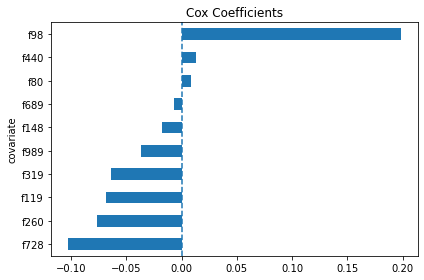

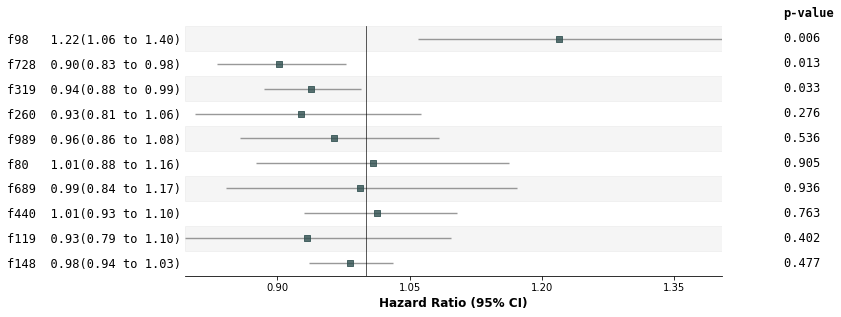

Percentiles not provided, using: [0.         0.33333333 0.66666667 1.        ]

Hazard Ratios (Train) -- each vs ref group
  G2 vs G1: HR = 1.742 (95% CI 1.285 - 2.360), p = 0.000343
  G3 vs G1: HR = 2.953 (95% CI 2.224 - 3.921), p = 6.93e-14

Hazard Ratios (Test)  -- each vs ref group
  G2 vs G1: HR = 1.431 (95% CI 1.041 - 1.968), p = 0.0273
  G3 vs G1: HR = 2.569 (95% CI 1.931 - 3.418), p = 9.6e-11


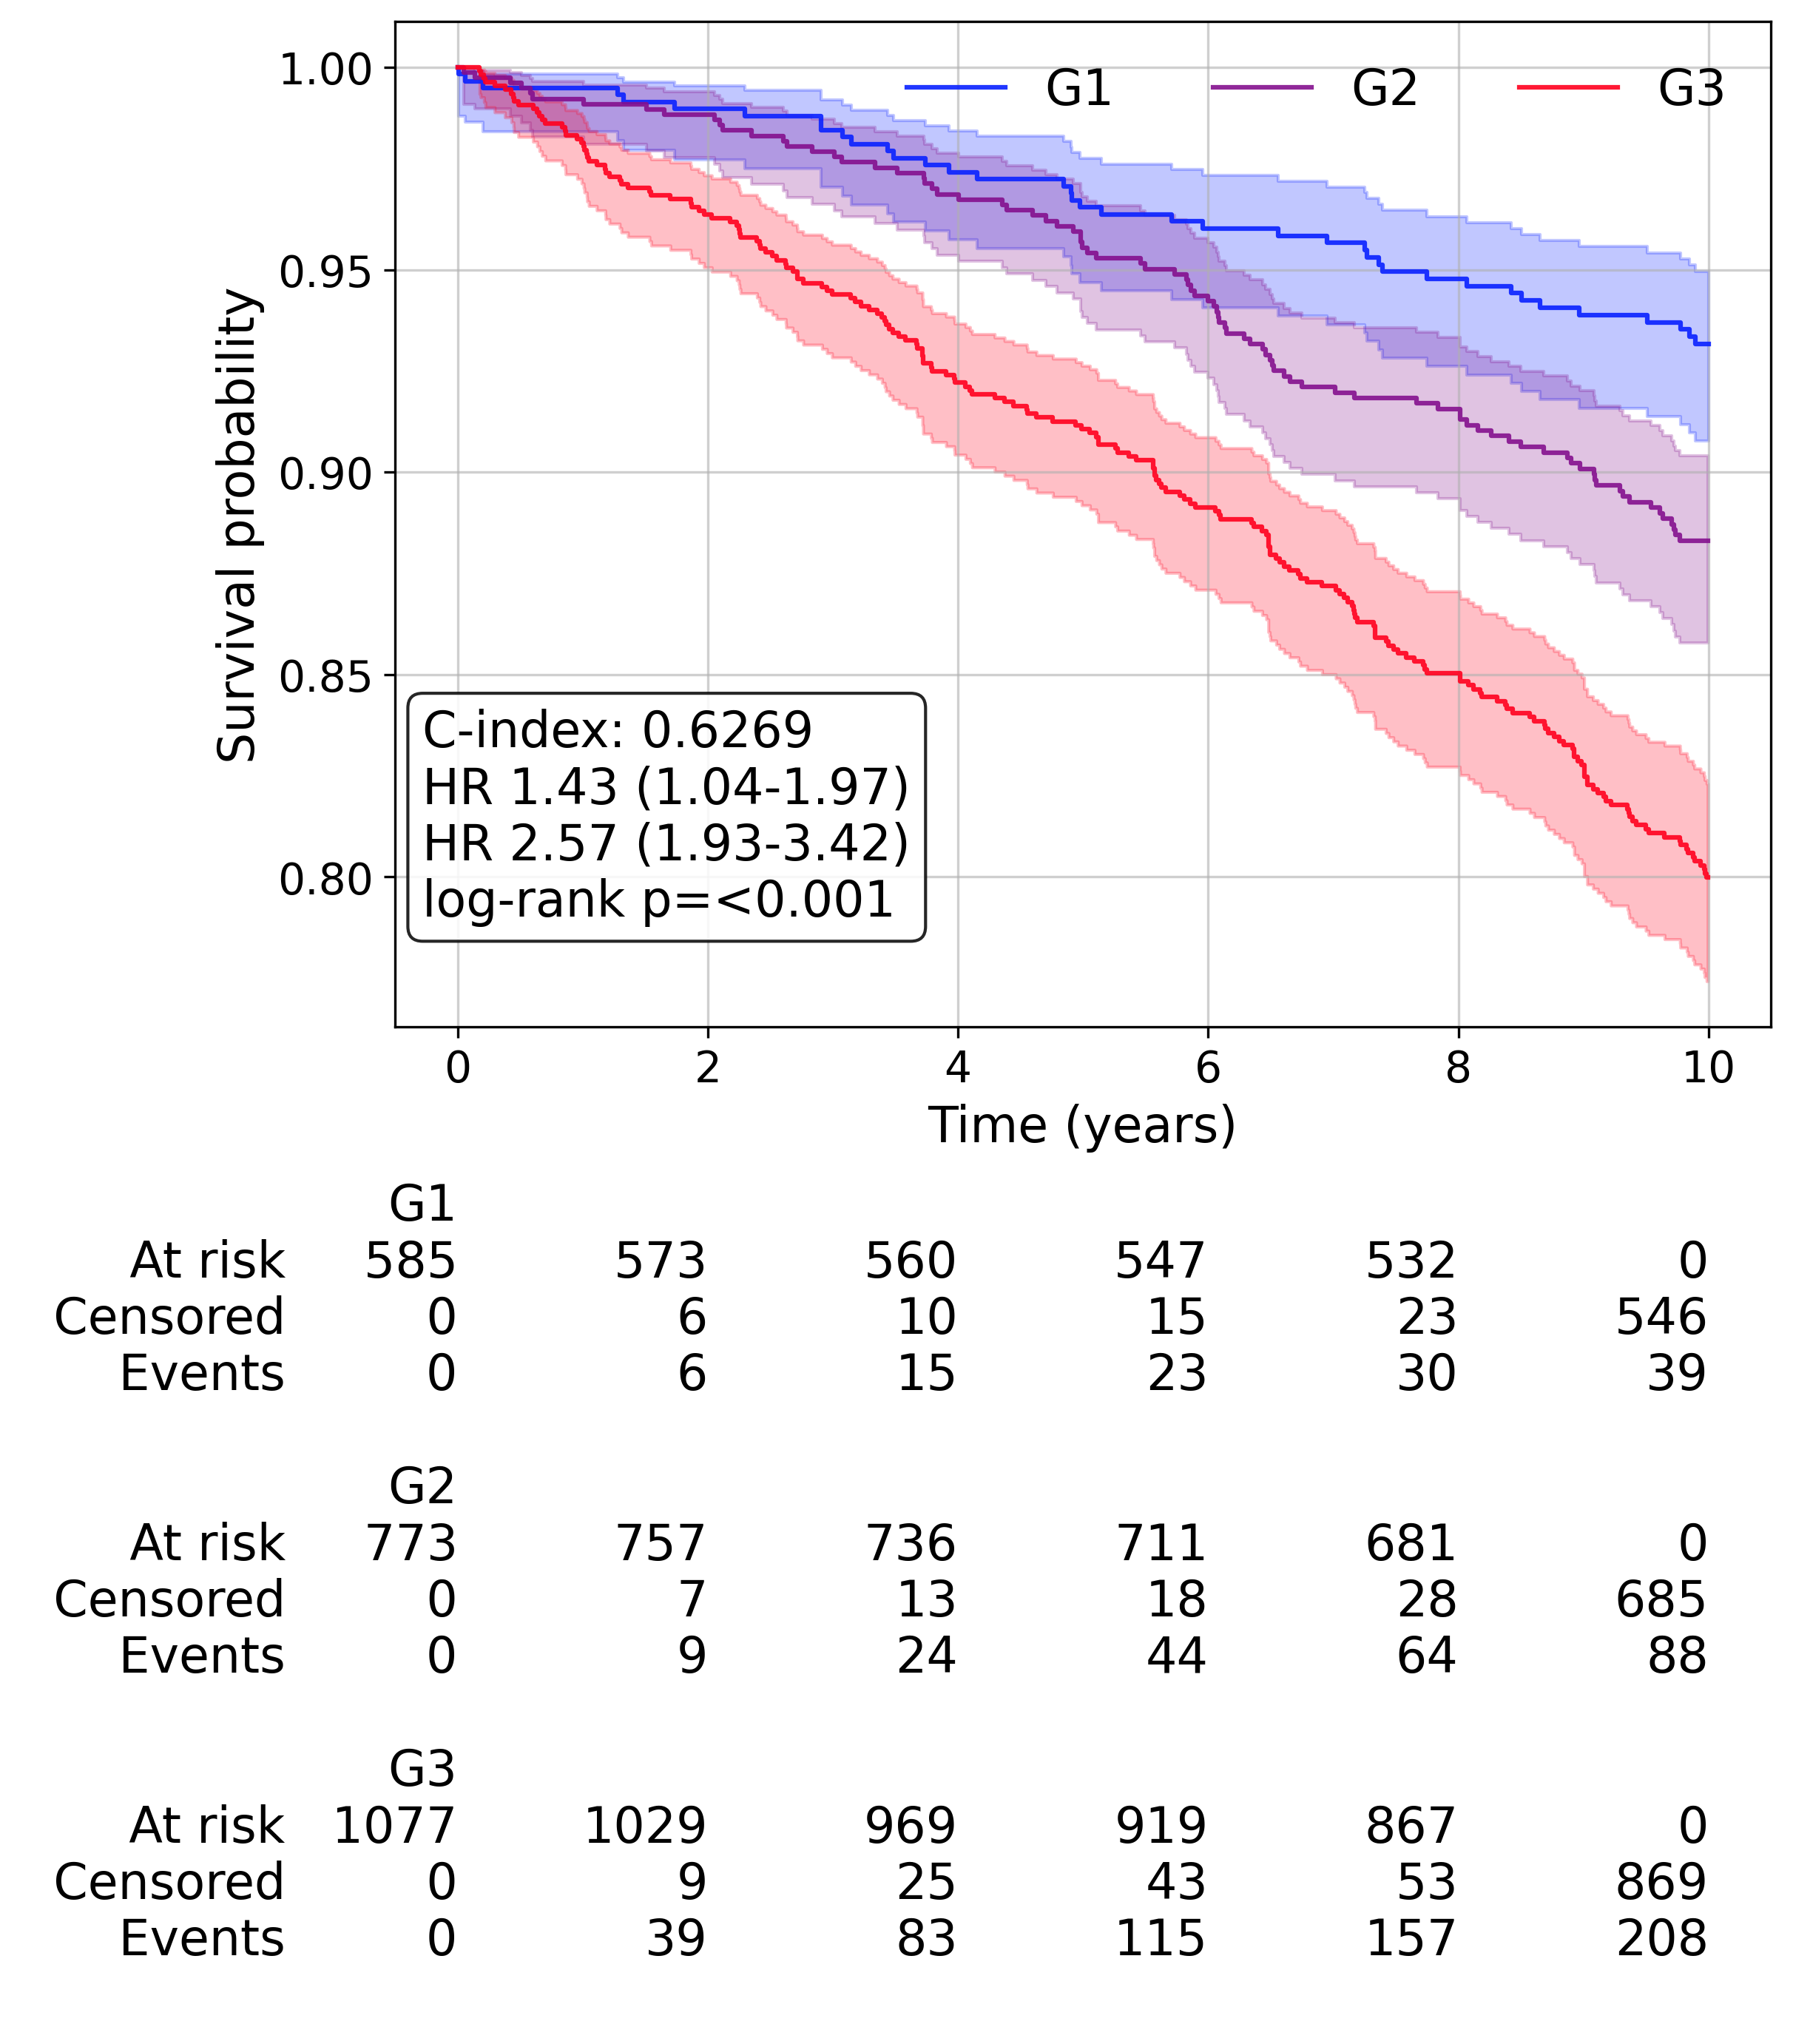

In [25]:
outputs = train_cox_model(train_df = meanpool["D1_cori"],
    test_df = meanpool["D2_cori"],
    selected_features = cori_features,
    time_col= time_col,
    event_col= event_col,
    organ_name="organ",
    save_dir=None,
    plot_km=True,
    plot_groups=[3],
    verbose=True)

## Test MMACE on D4

 train shape: (14159, 1069)
 test shape: (14763, 1069)


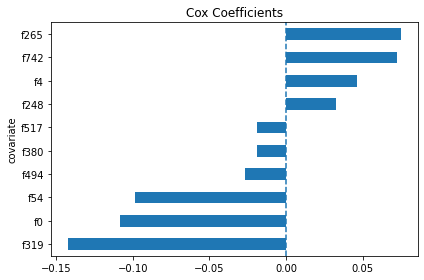

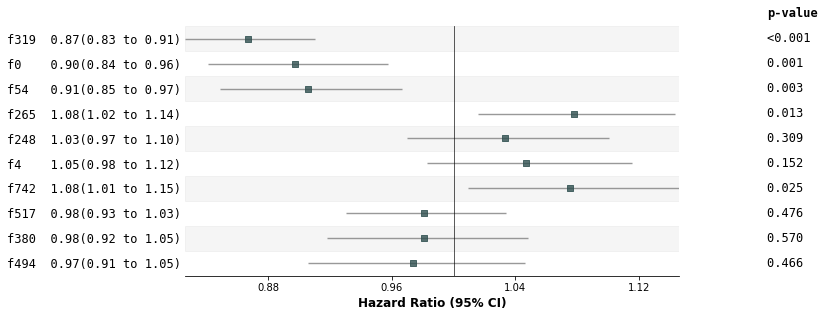

Percentiles not provided, using: [0.         0.33333333 0.66666667 1.        ]

Hazard Ratios (Train) -- each vs ref group
  G2 vs G1: HR = 1.226 (95% CI 1.074 - 1.400), p = 0.00259
  G3 vs G1: HR = 2.020 (95% CI 1.788 - 2.283), p = 1.38e-29

Hazard Ratios (Test)  -- each vs ref group
  G2 vs G1: HR = 1.218 (95% CI 1.071 - 1.386), p = 0.00271
  G3 vs G1: HR = 1.962 (95% CI 1.748 - 2.204), p = 4.04e-30


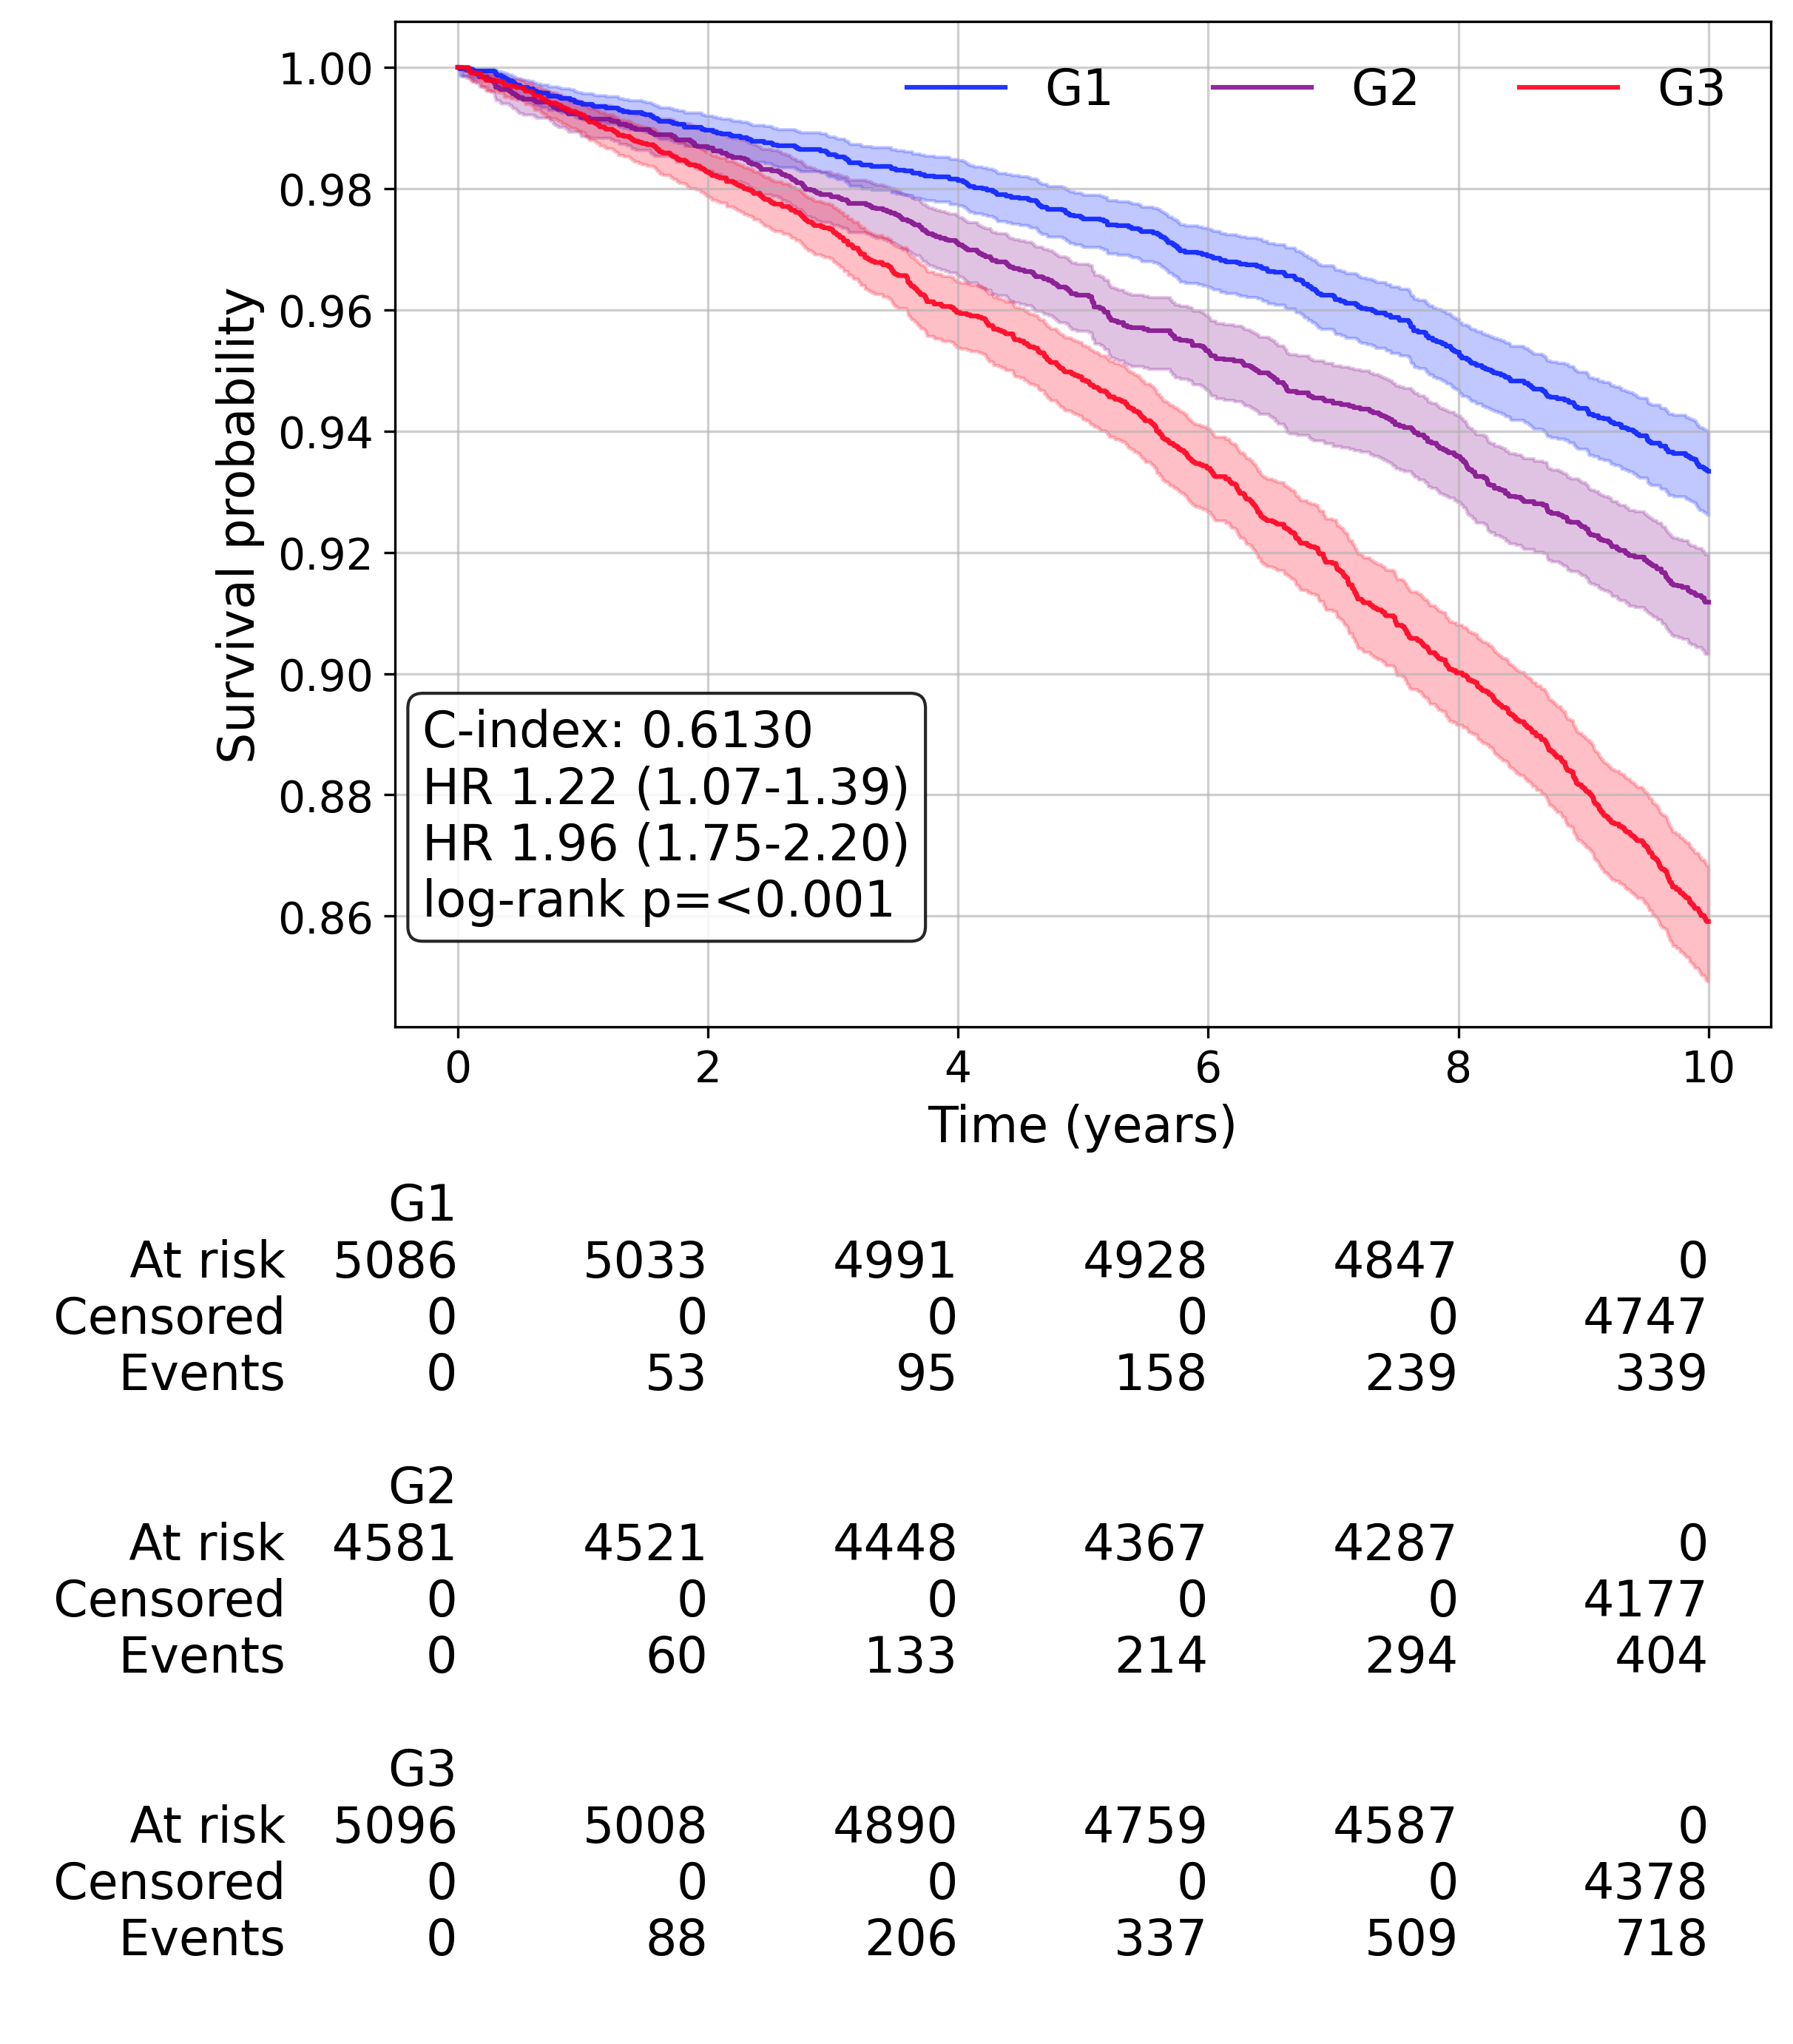

In [26]:


outputs = train_cox_model(train_df = meanpool["D3_mmace"],
    test_df = meanpool["D4_mmace"],
    selected_features = mmace_features, 
    time_col= time_col,
    event_col= event_col,
    organ_name="organ",
    save_dir=None,
    plot_km=True,
    plot_groups=[3],
    verbose=True)

## Test CORI on D4

 train shape: (2156, 1089)
 test shape: (14763, 1069)


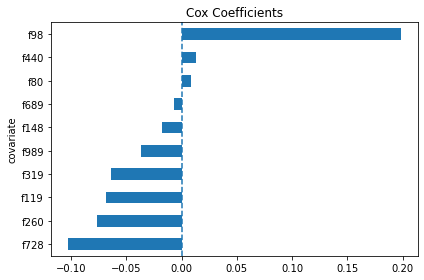

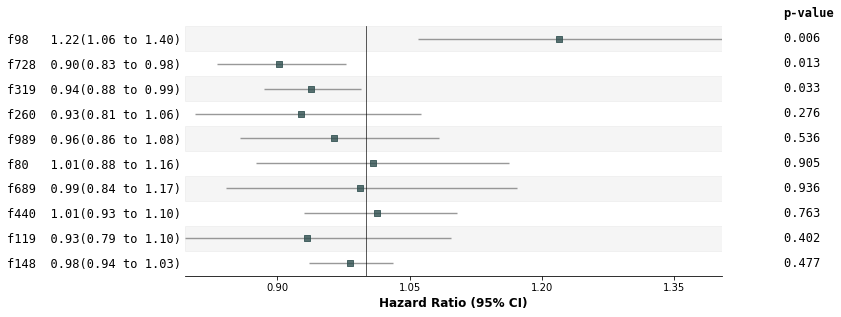

Percentiles not provided, using: [0.         0.33333333 0.66666667 1.        ]

Hazard Ratios (Train) -- each vs ref group
  G2 vs G1: HR = 1.742 (95% CI 1.285 - 2.360), p = 0.000343
  G3 vs G1: HR = 2.953 (95% CI 2.224 - 3.921), p = 6.93e-14

Hazard Ratios (Test)  -- each vs ref group
  G2 vs G1: HR = 2.415 (95% CI 2.014 - 2.896), p = 1.95e-21
  G3 vs G1: HR = 3.462 (95% CI 2.950 - 4.062), p = 2.41e-52


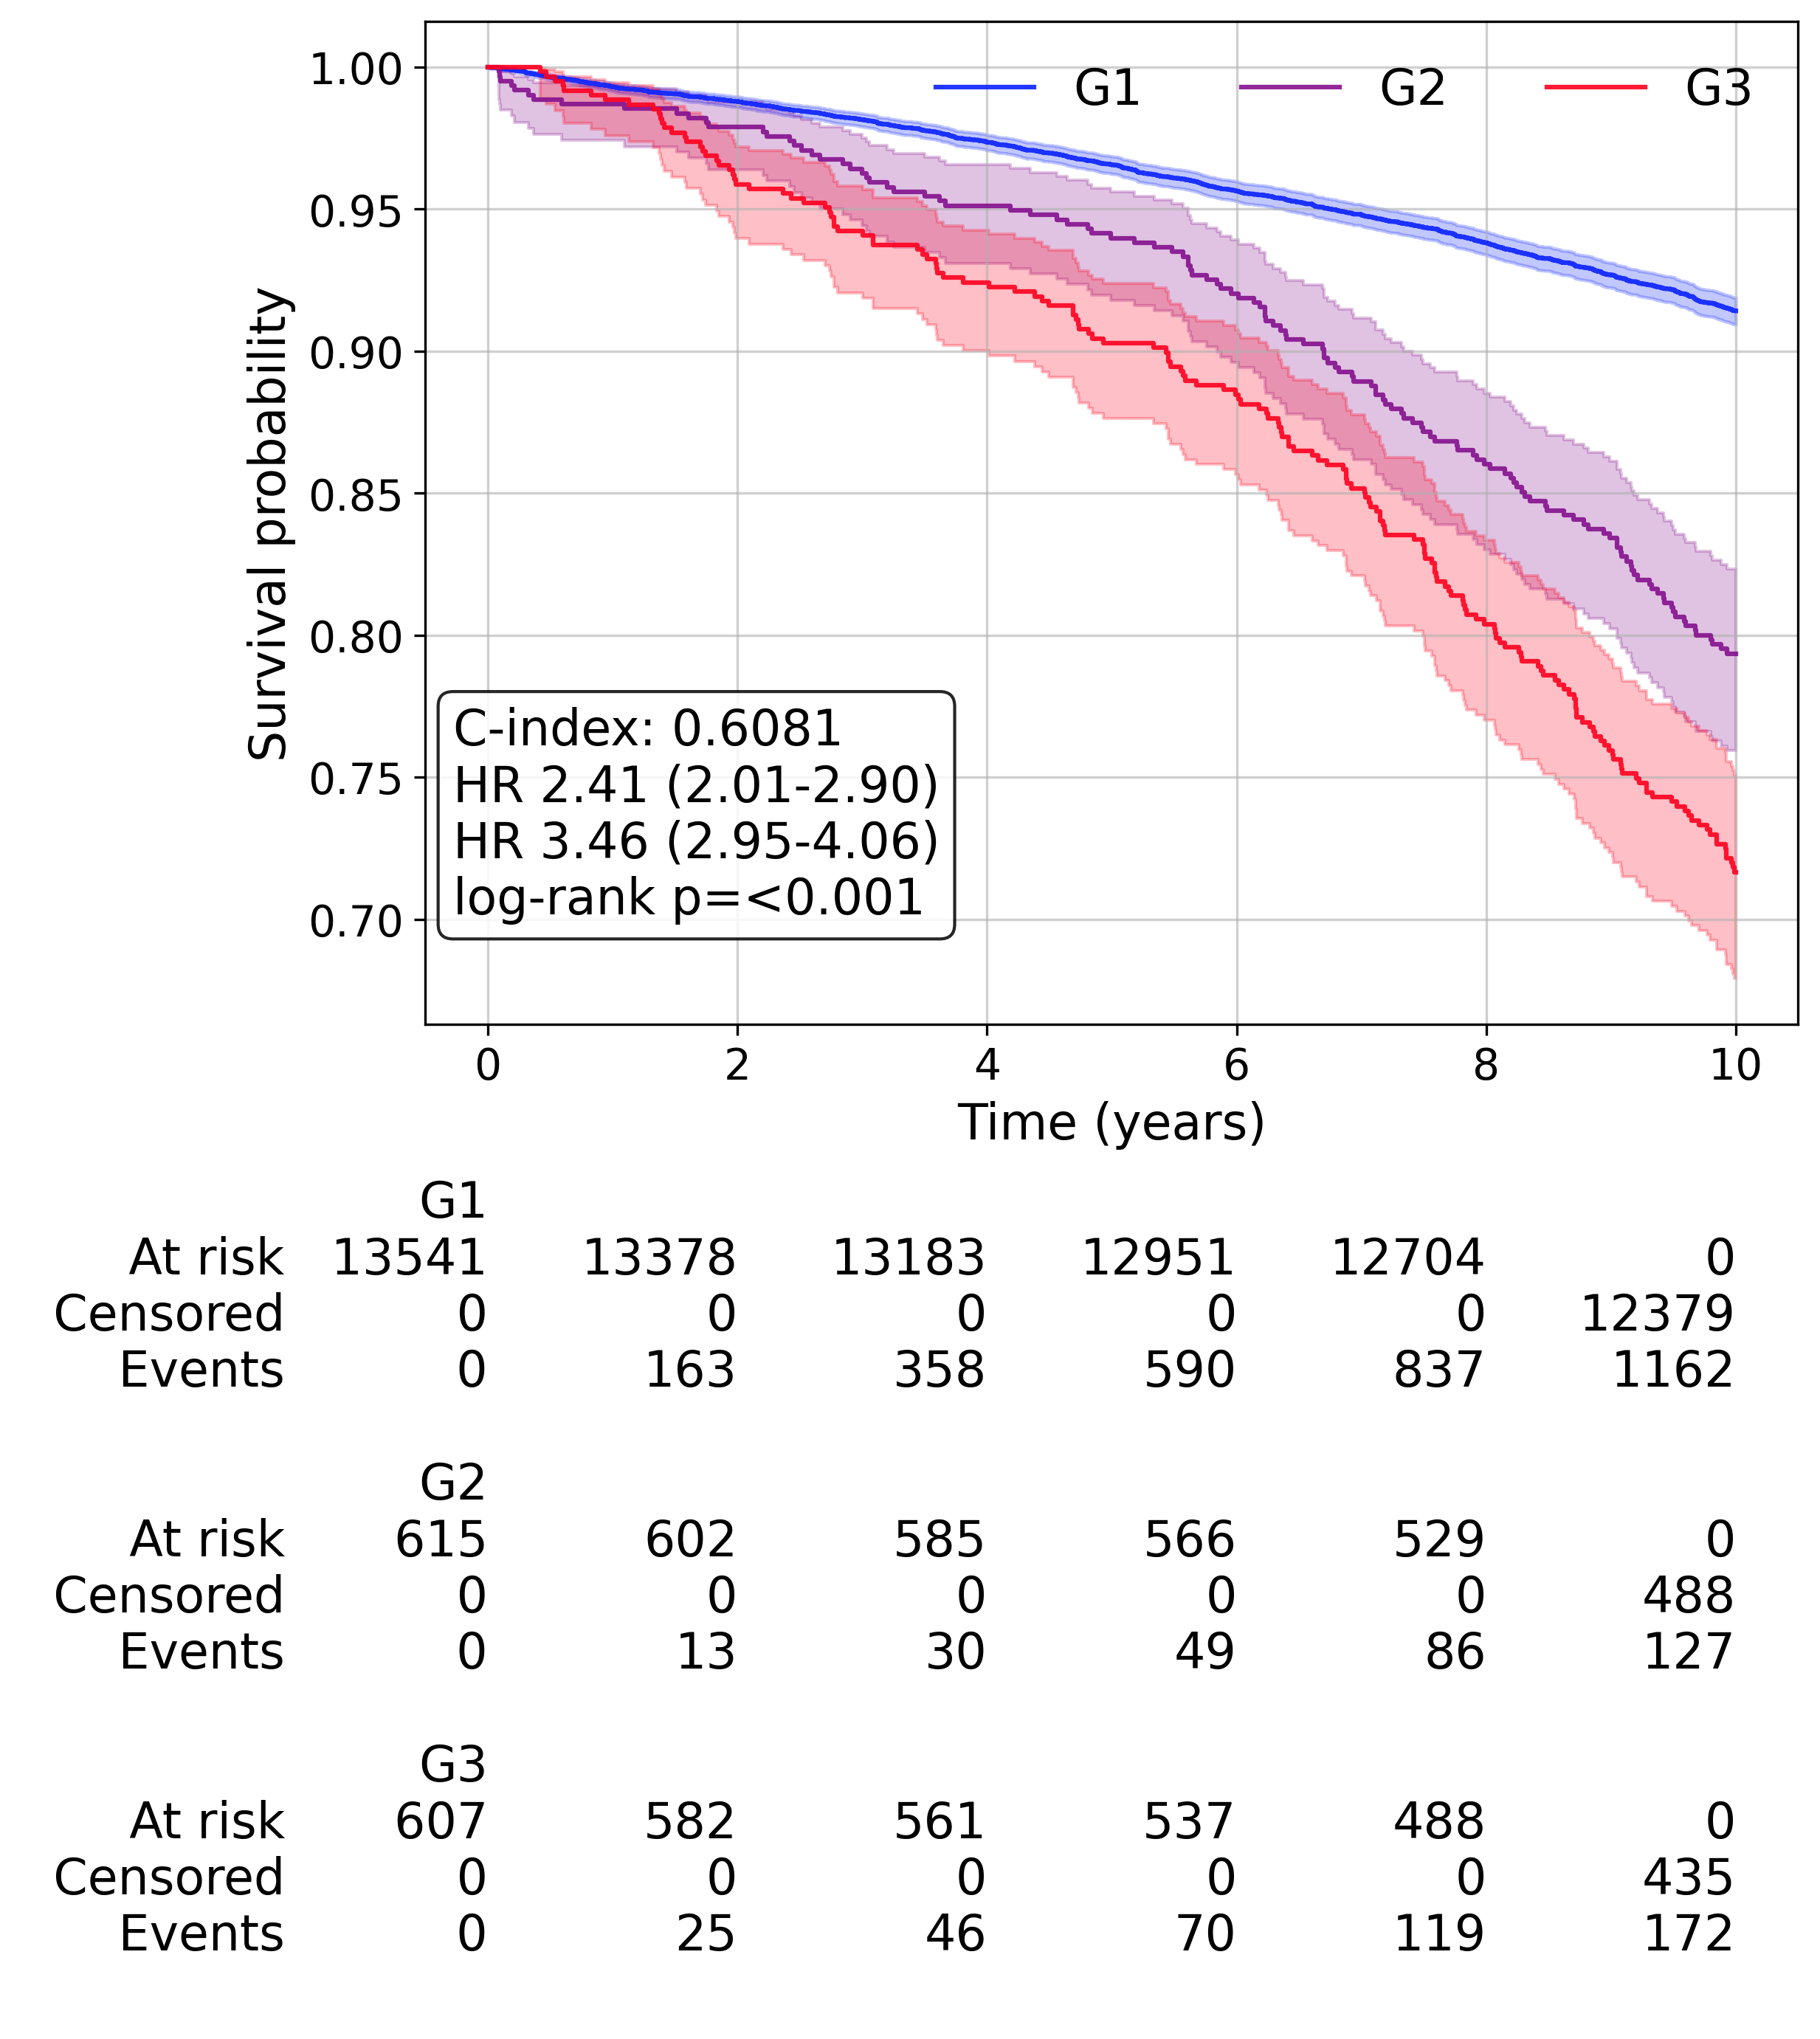

In [27]:
outputs = train_cox_model(train_df = meanpool["D1_cori"],
    test_df =meanpool["D4_cori"],
    selected_features = cori_features,
    time_col= time_col,
    event_col= event_col,
    organ_name="organ",
    save_dir=None,
    plot_km=True,
    plot_groups=[3],
    verbose=True)

## Test MMACE on D2

 train shape: (14159, 1069)
 test shape: (2435, 1089)


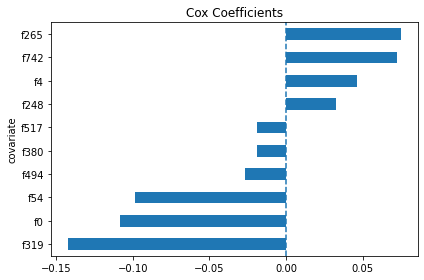

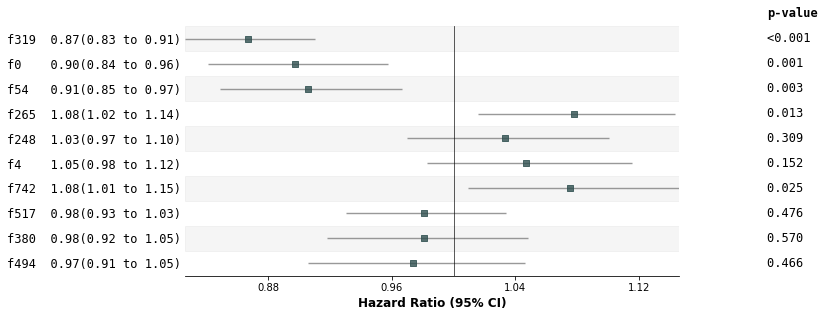

Percentiles not provided, using: [0.         0.33333333 0.66666667 1.        ]

Hazard Ratios (Train) -- each vs ref group
  G2 vs G1: HR = 1.226 (95% CI 1.074 - 1.400), p = 0.00259
  G3 vs G1: HR = 2.020 (95% CI 1.788 - 2.283), p = 1.38e-29

Hazard Ratios (Test)  -- each vs ref group
  G2 vs G1: HR = 11.701 (95% CI 0.185 - 741.746), p = 0.245
  G3 vs G1: HR = 2.431 (95% CI 0.055 - 106.967), p = 0.645


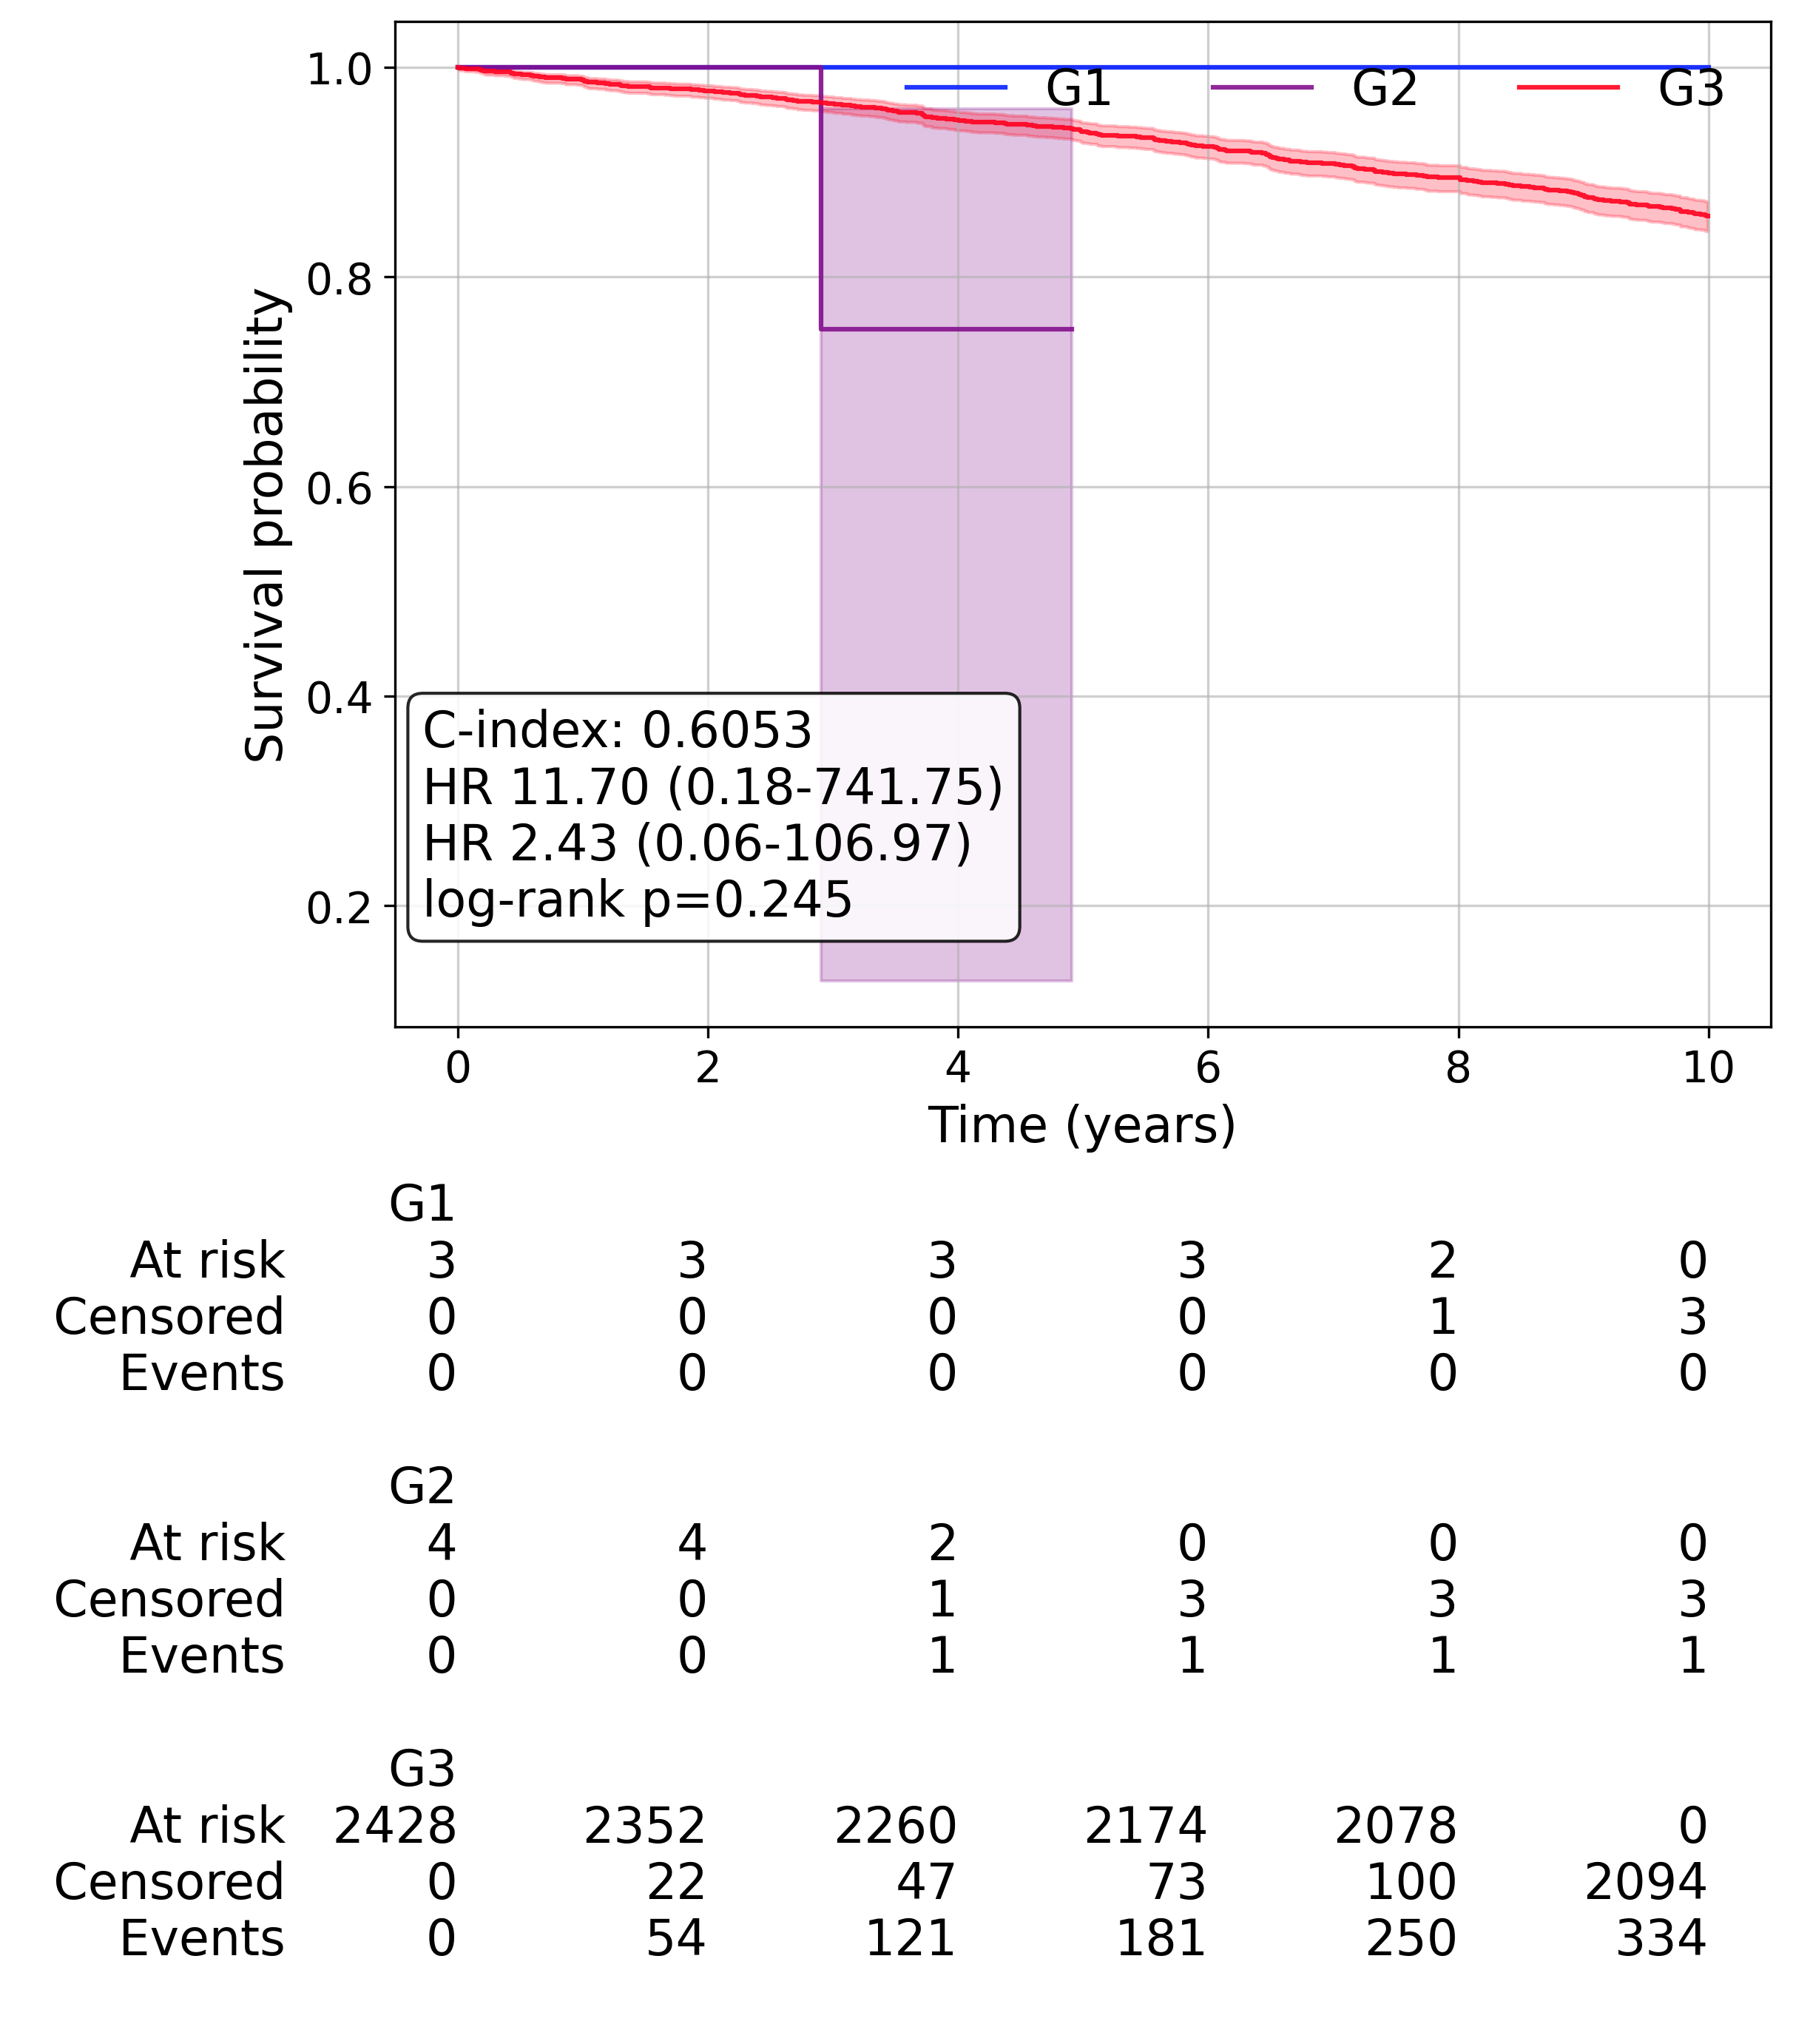

In [28]:

outputs = train_cox_model(train_df = meanpool["D3_mmace"],
    test_df = meanpool["D2_mmace"],
    selected_features =  mmace_features,
    time_col= time_col,
    event_col= event_col,
    organ_name="organ",
    save_dir=None,
    plot_km=True,
    plot_groups=[3],
    verbose=True)

## 13. Treatment-stratified and treatment-adjusted analyses

In [29]:
treatment_rows = []
for value, label in [(0, "No recorded systemic treatment"), (1, "Any recorded systemic treatment")]:
    subset = meanpool["D2_cori"].loc[meanpool["D2_cori"]["any_treatment"] == value]
    if subset["Y_mace"].sum() >= 5:
        treatment_rows.append(performance_row(subset, label, "CORI_z", "CORI_high", 500))
treatment_performance = pd.DataFrame(treatment_rows)
# save_table(treatment_performance, "Table_11A_treatment_stratified_CORI")

adjusted_treatment, _ = adjusted_cox(
    meanpool["D2_cori"], "CORI_z", [*TREATMENT_COLUMNS, *PRIMARY_ADJUSTMENT]
)
# save_table(adjusted_treatment, "Table_11B_treatment_adjusted_CORI")

interaction_rows = []
for treatment_column in [*TREATMENT_COLUMNS, "any_treatment"]:
    summary, _ = adjusted_cox(
        meanpool["D2_cori"], "CORI_z", PRIMARY_ADJUSTMENT,
        interaction_column=treatment_column,
    )
    interaction_term = f"CORI_z_x_{treatment_column}"
    row = summary.loc[summary["term"] == interaction_term].iloc[0].to_dict()
    row["treatment"] = treatment_column
    interaction_rows.append(row)
# save_table(pd.DataFrame(interaction_rows), "Table_11C_treatment_by_CORI_interactions")

KeyError: "['CORI_z'] not in index"

## 14. Center-level performance

In [30]:
center_data = meanpool["D2_cori"].copy()
center_data["reporting_center"] = center_data["center"].replace({"Liverpool": "Liverpool + Swansea", "Swansea": "Liverpool + Swansea"})
center_rows = []
for center, subset in center_data.groupby("reporting_center"):
    if subset["Y_mace"].sum() >= 5:
        center_rows.append(performance_row(subset, center, "CORI_z", "CORI_high", 500))
center_table = pd.DataFrame(center_rows)
save_table(center_table, "Table_07_center_level_CORI_performance")
forest_plot(center_table, "cohort", "HR", "HR_low", "HR_high", "CORI high versus low by center", FIGURE_DIR / "Figure_S_center_forest")

KeyError: "['CORI_z'] not in index"

## 15. Age, sex, treatment, and cancer-site subgroup analyses

In [ ]:
# ============================================================
# Prespecified CORI subgroup associations in held-out D2
# ============================================================

d2_subgroups = meanpool["D2_cori"].copy()

d2_subgroups["age_group"] = np.where(
    d2_subgroups["age"] < 60,
    "Age <60",
    "Age ≥60",
)

d2_subgroups["sex_group"] = np.where(
    d2_subgroups["female"] == 1,
    "Female",
    "Male",
)

d2_subgroups["treatment_group"] = np.where(
    d2_subgroups["any_treatment"] == 1,
    "Recorded treatment",
    "No recorded treatment",
)


# ------------------------------------------------------------
# Age, sex, and recorded-treatment subgroups
# ------------------------------------------------------------

subgroup_tables = [
    subgroup_cox(
        d2_subgroups,
        score_column="CORI_z",
        subgroup_column="age_group",
        minimum_events=20,
        covariates=PRIMARY_ADJUSTMENT,
    ),
    subgroup_cox(
        d2_subgroups,
        score_column="CORI_z",
        subgroup_column="sex_group",
        minimum_events=20,
        covariates=PRIMARY_ADJUSTMENT,
    ),
    subgroup_cox(
        d2_subgroups,
        score_column="CORI_z",
        subgroup_column="treatment_group",
        minimum_events=15,
        covariates=PRIMARY_ADJUSTMENT,
    ),
]


# ------------------------------------------------------------
# Cancer-site subgroups
# ------------------------------------------------------------

for site in CANCER_SITE_COLUMNS:
    if site not in d2_subgroups.columns:
        continue

    site_data = d2_subgroups.loc[
        d2_subgroups[site]
        .fillna(0)
        .astype(int)
        .eq(1)
    ].copy()

    events = int(site_data["Y_mace"].sum())

    if events < 20:
        continue

    summary, _ = adjusted_cox(
        site_data,
        score_column="CORI_z",
        covariates=PRIMARY_ADJUSTMENT,
        penalizer=0.01,
    )

    score_row = summary.loc[
        summary["term"] == "CORI_z"
    ].iloc[0]

    subgroup_tables.append(
        pd.DataFrame(
            [
                {
                    "subgroup": "cancer_site",
                    "level": site.replace(
                        "_present",
                        "",
                    ),
                    "N": int(score_row["N"]),
                    "events": int(
                        score_row["events"]
                    ),
                    "HR": score_row["HR"],
                    "HR_low": score_row["HR_low"],
                    "HR_high": score_row["HR_high"],
                    "p": score_row["p"],
                    "dropped_constant": (
                        score_row[
                            "dropped_constant"
                        ]
                    ),
                }
            ]
        )
    )


# ------------------------------------------------------------
# Combine and save
# ------------------------------------------------------------

subgroup_tables = [
    table
    for table in subgroup_tables
    if table is not None
    and not table.empty
]

subgroups = pd.concat(
    subgroup_tables,
    ignore_index=True,
)

subgroup_labels = {
    "age_group": "Age",
    "sex_group": "Sex",
    "treatment_group": "Treatment",
    "cancer_site": "Cancer site",
}

subgroups["forest_label"] = (
    subgroups["subgroup"]
    .map(subgroup_labels)
    .fillna(subgroups["subgroup"])
    + ": "
    + subgroups["level"].astype(str)
)

subgroups = (
    subgroups
    .sort_values(
        ["subgroup", "level"]
    )
    .reset_index(drop=True)
)

display(subgroups)

save_table(
    subgroups,
    "Table_12_subgroup_CORI_associations",
)


# ------------------------------------------------------------
# Forest plot
# The keyword names must match src/plots.py exactly.
# ------------------------------------------------------------

forest_plot(
    df=subgroups,
    label="forest_label",
    estimate="HR",
    lower="HR_low",
    upper="HR_high",
    title=(
        "CORI association across "
        "prespecified subgroups"
    ),
    path=(
        FIGURE_DIR
        / "Figure_S_subgroup_forest"
    ),
)